In [1]:
import numpy as np
from numpy.linalg import solve
from scipy.linalg import eig
from dataclasses import dataclass
from typing import Optional, Callable, Tuple
import matplotlib.pyplot as plt
from scipy.special import j1
from types import SimpleNamespace
import warnings
import os
import time
# Trapezoid shim (NumPy renamed trapz->trapezoid)
try:
    from numpy import trapezoid as trapz
except Exception:
    try:
        from scipy.integrate import trapezoid as trapz
    except Exception:
        from numpy import trapz
Complex = np.complex128
from numba import njit, prange
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm
import math
from typing import List

from tqdm.auto import tqdm  # optional
from numba import set_num_threads, get_num_threads
set_num_threads(8)         # or whatever
print("Numba threads:", get_num_threads())

from scipy.constants import epsilon_0

import utility_files as util

from scipy.constants import epsilon_0

from scipy.special import j1

np.set_printoptions(
    precision=3,
    suppress=False,
)


%load_ext autoreload
%autoreload 2

Numba threads: 8


In [2]:
# ---------------------------------------------------------------------------
# Voigt 6 ↔ 4th-rank converters
# ---------------------------------------------------------------------------

# Standard 6-index Voigt mapping:
# 0↔(0,0), 1↔(1,1), 2↔(2,2), 3↔(1,2), 4↔(0,2), 5↔(0,1)

_VOIGT_PAIRS = [(0,0),(1,1),(2,2),(1,2),(0,2),(0,1)]
_ALPHA = np.array([1,1,1,1,1,1], float)
_VOIGT_6_LOOKUP = {}
for a, (i, j) in enumerate(_VOIGT_PAIRS):
    _VOIGT_6_LOOKUP[(i, j)] = a
    _VOIGT_6_LOOKUP[(j, i)] = a  # minor symmetry

# --- Voigt → full 4th-rank mapping ---

_voigt_to_pair = np.array([
    [0, 0],  # 0 -> 11
    [1, 1],  # 1 -> 22
    [2, 2],  # 2 -> 33
    [1, 2],  # 3 -> 23
    [0, 2],  # 4 -> 13
    [0, 1],  # 5 -> 12
], dtype=np.int64)

KIND_ELASTIC = np.int8(0)
KIND_PIEZO   = np.int8(1)


C6_LN = np.array([
    [203.0, 57.3, 75.2,  -8.5,  0.0,  0.0],
    [ 57.3,203.0, 75.2,   8.5,  0.0,  0.0],
    [ 75.2, 75.2,242.4,   0.0,  0.0,  0.0],
    [ -8.5,  8.5,  0.0,  59.5,  0.0,  0.0],
    [  0.0,  0.0,  0.0,   0.0, 59.5, -8.5],
    [  0.0,  0.0,  0.0,   0.0, -8.5, (203.0-57.3)/2],
], np.float64) * 1e9

rho_LN = 4650.0
L_LN   = 115e-6

#import numpy as np

# LiNbO3 piezoelectric stress coefficients (C/m^2)
e15 = 3.83
e22 = 2.37
e31 = 0.23
e33 = 1.30

# 3×6 Voigt-form piezoelectric tensor [e]
# Rows:    D1,   D2,   D3
# Cols: S1,S2,S3,S4,S5,S6  (11,22,33,23,13,12)
e6_LN = np.array([
    [   0.0,   0.0,   0.0,   0.0,  e15, -e22],
    [ -e22,   e22,   0.0,  e15,   0.0,  0.0],
    [  e31,   e31,   e33,  0.0,   0.0,  0.0]
], dtype=np.float64)

# You fill these with your actual tensors:
#   e6_LN   : (3x6) piezo matrix
#   eps3_LN : (3x3) dielectric tensor
#e6_LN   = ...  # TODO: insert LiNbO3 e_ij in Voigt
#eps3_LN = ...  # TODO: insert LiNbO3 permittivity tensor
eps11 = 44.3
eps33=27.9

eps3_LN = np.array([[44.3,0.0,0.0],
                 [0.0,44.3,0.0],
                 [0.0,0.0,27.9]], dtype=np.float64)*epsilon_0
# after defining e6_LN
e_ijk_LN = util.e6_voigt_to_eijk(e6_LN)
tan_LN=5e-3
tan_eps_LN=0.0

# ---------- Sapphire ----------
C6_sap = np.array([
    [497,164,113,  -23,  0,  0],
    [164,497,113,   23,  0,  0],
    [113,113,501,    0,  0,  0],
    [ -23,  23,  0, 147,  0,  0],
    [  0,   0,  0,   0, 147,-23],
    [  0,   0,  0,   0,-23,(497-164)/2],
],  dtype=np.float64) * 1e9  # Pa

rho_sap = 3980.0   # kg/m^3
L_sap   = 1e-2    # m
tan_sap = 4e-4

# ---------- Indium (isotropic) ----------
B_in   = 35.0e9      # bulk modulus [Pa]
G_in   = 4.4e9       # shear modulus [Pa]
rho_in = 1928.3      # density [kg/m^3]

lam_in = B_in - 2.0*G_in/3.0   # Lamé λ
mu_in  = G_in                  # Lamé μ

C11_in = 192#lam_in + 2.0*mu_in
C12_in =163# lam_in
C44_in =42 # mu_in

C6_in = np.array([
    [C11_in, C12_in, C12_in, 0.0,   0.0,   0.0],
    [C12_in, C11_in, C12_in, 0.0,   0.0,   0.0],
    [C12_in, C12_in, C11_in, 0.0,   0.0,   0.0],
    [0.0,    0.0,    0.0,    C44_in,0.0,   0.0],
    [0.0,    0.0,    0.0,    0.0,   C44_in,0.0],
    [0.0,    0.0,    0.0,    0.0,   0.0,   C44_in],
], dtype=np.float64)*1e9

L_in   = 350e-9   # m
tan_in = 1e-2

f_ref_b=1e8
omega_ref = 2.0 * np.pi * f_ref_b

theta_cut=90-36.7

# frequency grid
df    = 0.05e6
f_min = 10e6
f_max = 1e9
Nf    = int((f_max - f_min)/df) + 1
freqs = np.linspace(f_min, f_max, Nf)

# aperture + slowness integration params
a_radius      = 5e-4
Nphi          = 90

du=np.pi/24
# block params
R_max  = 1.5
tol_im = 1e-15
tol_s  = 1e-18

# BCs
mech_bc_flag_topwall  = 0    # 0 free, 1 clamped
top_elec_flag         = 3    # passthrough at top (TEM handles electrical)
top_Z_elec            = 0.0 + 0.0j
top_passthrough_idx   = 3    # your chosen free amplitude index

mech_bc_flag_backwall = 0    # sapphire back surface free

Z0 = 50.0

In [4]:
C4_LN = util.voigt6_to_cijkl(C6_LN, _VOIGT_PAIRS)
C4_sap = util.voigt6_to_cijkl(C6_sap, _VOIGT_PAIRS)

rot_C4_LN_eff = util.rotate_tensor_4_rank(C4_LN,theta_cut)
rot_e_ijk_LN=util.rotate_tensor_3_rank(e_ijk_LN,theta_cut)
rot_eps3_LN=util.rotate_tensor_2_rank(eps3_LN,theta_cut)

layers= [
    {
        "name": "LiNbO3",
        "kind": "piezo",       # <— tells the cache builder to use piezo kernel
        "C4_eff": rot_C4_LN_eff,   # 3×3×3×3 complex stiffness
        "e_ijk": rot_e_ijk_LN,     # 3×3×3 piezo tensor
        "eps_tensor": rot_eps3_LN,  # 3×3 complex permittivity
        "rho": rho_LN,
        "L": L_LN,
        "tan_delta": tan_LN,
        "tan_eps": tan_eps_LN,

        # Electric BC at the *bottom* interface of the piezo layer
        "bottom_elec_flag": 0,      # 0 short, 1 open, 2 Z
        "bottom_Z_elec": 0.0 + 0.0j,
    },
    # {
    #     "name": "Indium",
    #     "kind": "elastic",
    #     "C4_eff": C4_in_eff,
    #     "rho": rho_in,
    #     "L": L_in,
    #     "tan_delta": tan_in,
    # },
    {
        "name": "Sapphire",
        "kind": "elastic",
        "C4_eff": C4_sap,
        "rho": rho_sap,
        "L": L_sap,
        "tan_delta": tan_sap,
    },
]

td_fns_list = [
    lambda f: util.tan_delta_powerlaw(f, tan0=3e-4, f0_hz=100e6, exponent=0.3, tan_max=2e-3),
    lambda f: util.tan_delta_debye(f, tau_s=1/(2*np.pi*80e6), Delta=2e-3, tan_bg=4e-4, tan_max=5e-3),
]

freqs = np.asarray(freqs, dtype=np.float64)
edges, f_ref_blocks = util.make_log_blocks_from_ratio(f_min, f_max, R_max=R_max)

omegas_upper=[]

min_omega_upper=40
max_omega_upper=400
for i in range(len(f_ref_blocks)):
    if edges[i]<=2e6:
        omeg=max_omega_upper
    elif 2e6<=edges[i]<=10e6:
        omeg=400
    elif 10e6<=edges[i]<=20e6:
        omeg=1250
    elif 20e6<=edges[i]<=50e6:
        omeg=100
    elif 50e6<=edges[i]<=100e6:
        omeg=75
    else:
        omeg=min_omega_upper
    omegas_upper.append(omeg)

omega_s_a_max=np.array(omegas_upper,dtype=np.float64)

td_fns = {
    "LiNbO3":  lambda f: util.tan_delta_powerlaw(f, tan0=4e-4, f0_hz=50e6, exponent=0.7, tan_max=8e-3),
    "Sapphire":lambda f: min(
        util.tan_delta_debye(f, tau=1/(2*np.pi*50e6), Delta=4e-3, tan_bg=1e-4),
        1e-4
    ),
}

In [8]:
f_ref_blocks

array([1.212e+07, 1.778e+07, 2.610e+07, 3.831e+07, 5.623e+07, 8.254e+07,
       1.212e+08, 1.778e+08, 2.610e+08, 3.831e+08, 5.623e+08, 8.254e+08])

In [ ]:
blocks = util.build_slowness_blocks_streaming(
    freqs=freqs,
    edges=edges,
    f_ref_blocks=f_ref_blocks,
    omega_s_a_max=omega_s_a_max,
    du=du,
    Nphi=Nphi,
    a_radius=a_radius,
    layers=layers,

    mech_bc_flag_topwall=mech_bc_flag_topwall,
    top_elec_flag=top_elec_flag,
    top_Z_elec=top_Z_elec,
    top_elec_passthrough_idx=3,
    mech_bc_flag_backwall=mech_bc_flag_backwall,

    tan_delta_block_fns_per_layer=td_fns,   # ✅ now accepted
    store_top_full_modes=False,
    store_top_Bf=True,
    KIND_ELASTIC=KIND_ELASTIC,
    KIND_PIEZO=KIND_PIEZO
)

print("Number of blocks:", len(blocks))

# 3) Inspect the first block to confirm layout
blk0 = blocks[0]
out0 = blk0[7]  # (idx, omegas, s_vals, const_prefac, piston, L_layers, n_modes, out)

print("len(out0) =", len(out0))
print("out0 shapes:", [getattr(x, "shape", None) for x in out0])

Building slowness blocks:   0%|          | 0/1 [00:00<?, ?it/s]

Number of blocks: 1
len(out0) = 14
out0 shapes: [(3057, 90, 2, 4), (3057, 90, 2, 4), (3057, 90, 1, 4, 4), (3057, 90, 1, 4, 4), (3057, 90, 1, 4, 4), (3057, 90, 1, 4, 4), (3057, 90, 4, 4), (3057, 90, 4, 4), (3057, 90, 4, 4), (3057, 90, 4), (3057, 90, 4), (3057, 90, 4), (3057, 90, 4), (3057, 90, 4)]


In [ ]:
blocks_elec = util.compress_blocks_fulltop_to_elec_only(
    blocks,
    mech_bc_flag_topwall=mech_bc_flag_topwall,
    top_passthrough_idx=3,
)

L_layers = np.array([lay["L"] for lay in layers], dtype=np.float64)

In [14]:
I_omega2 = util.integrate_all_blocks_streaming_inplace_elec_only(
    freqs=freqs,
    blocks=blocks_elec,
    L_layers=L_layers,
    a_radius=a_radius,
    Z0=Z0,
    show_progress_blocks=True,
)

Integrating blocks:   0%|          | 0/1 [00:00<?, ?it/s]

Exception ignored in: <function tqdm.__del__ at 0x000001F249C60160>
Traceback (most recent call last):
  File "c:\Users\maran\anaconda3\envs\olin_env\lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "c:\Users\maran\anaconda3\envs\olin_env\lib\site-packages\tqdm\notebook.py", line 282, in close
    self.disp(bar_style='success', check_delay=False)
AttributeError: 'tqdm' object has no attribute 'disp'


In [ ]:
Zimp2=50*(1+I_omega2)/(1-I_omega2)
ZimpE=np.conj(Zimp2)

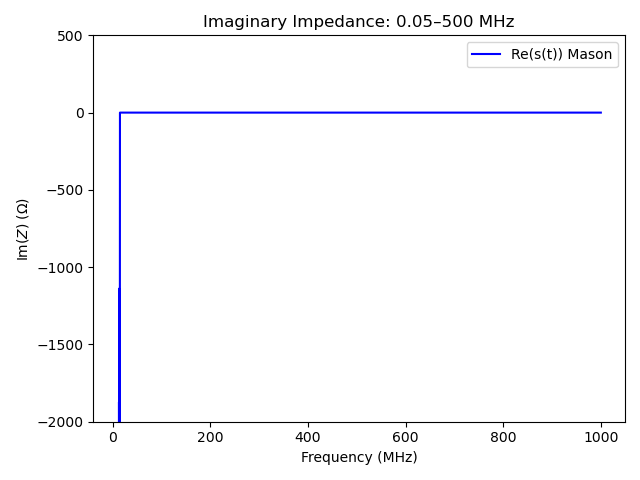

In [ ]:
%matplotlib widget
m = (freqs >= f_min) & (freqs <= f_max)

fig, ax = plt.subplots()
#ax.plot(freqs[m]/1e6, np.imag((Ze[m])),label="Re(s(t)) Mason", color="orange")
ax.plot(freqs[m]/1e6, np.imag(ZimpE[m]),label="Re(s(t)) Mason", color="blue")

ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel(r"Im$(Z)$ ($\Omega$)")
ax.set_title(r"Imaginary Impedance: 0.05–500 MHz")  # title
ax.legend()
plt.ylim(-2000,500)
fig.tight_layout()
fig.savefig("Zimag_to500MHz_zoom2.png", dpi=300, bbox_inches="tight")
plt.show()




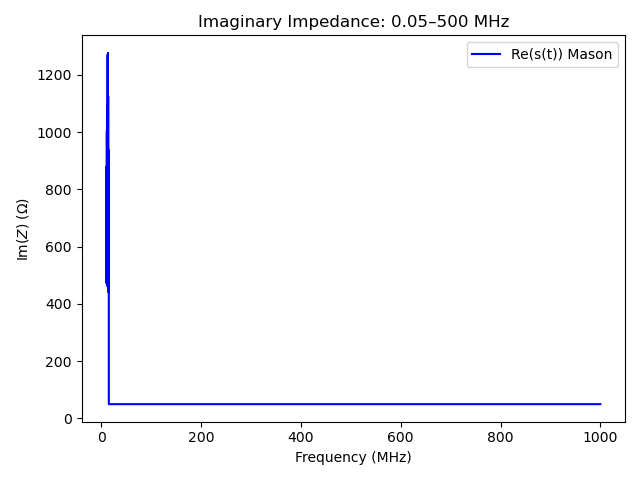

In [20]:
%matplotlib widget
#freqplt=np.where(freqs>=10e6 and freqs<=200e6)
      # optional: nuke old widget figures
#fmin, fmax = 0e6, 200e6
m = (freqs >= f_min) & (freqs <= f_max)

fig, ax = plt.subplots()
#ax.plot(freqs[m]/1e6, np.real((Ze[m])),label="Re(s(t)) Mason", color="orange")
ax.plot(freqs[m]/1e6, np.real(np.conj(Zimp2[m])),label="Re(s(t)) Mason", color="blue")

#ax.plot(freqs[m]/1e6, np.imag(np.conj(Zimp3[m])))
#ax.plot(freqs[m]/1e6, np.imag(np.conj(Zimp4[m])))
#ax.set_xlim(fmin/1e6, fmax/1e6)
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel(r"Im$(Z)$ ($\Omega$)")
ax.set_title(r"Imaginary Impedance: 0.05–500 MHz")  # title
ax.legend()
#plt.ylim(-2000,500)
fig.tight_layout()
fig.savefig("Zreal_to500MHz.png", dpi=300, bbox_inches="tight")
plt.show()



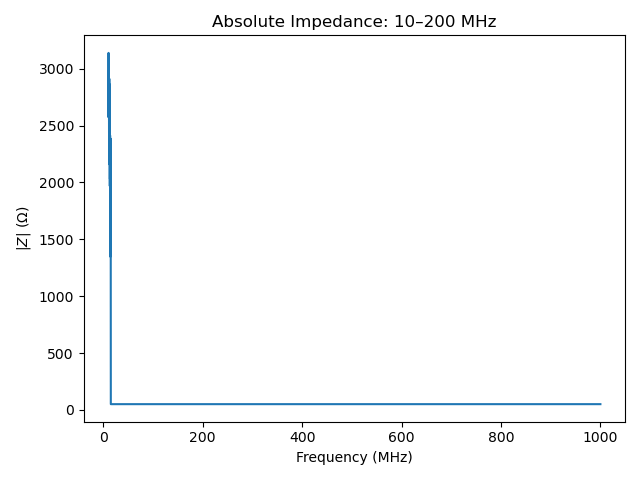

In [21]:
#%matplotlib widget
#freqplt=np.where(freqs>=10e6 and freqs<=200e6)
      # optional: nuke old widget figures
      # optional: nuke old widget figures
#fmin, fmax = 0e6, 300e6
m = (freqs >= f_min) & (freqs <= f_max)

fig, ax = plt.subplots()
ax.plot(freqs[m]/1e6, np.abs(np.conj(Zimp2[m])))
# ax.plot(freqs[m]/1e6, np.abs(np.conj(Zimp2[m])))
# ax.plot(freqs[m]/1e6, np.abs(np.conj(Zimp3[m])))
# ax.plot(freqs[m]/1e6, np.abs(np.conj(Zimp4[m])))
#ax.set_xlim(fmin/1e6, fmax/1e6)
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel(r"$|Z|$ ($\Omega$)")
ax.set_title(r"Absolute Impedance: 10–200 MHz")  # title

fig.tight_layout()
#fig.savefig("Zabsolute_200to400MHz.png", dpi=300, bbox_inches="tight")
plt.show()


In [24]:

Gamma2 = util.reflection_coeff(ZimpE, Z0=50.0)
Gamma2 *= util.window_1d("blackman", len(freqs))

P = util.rect_pulse_spectrum(freqs_hz=freqs,T_s=0.5e-6, t0_s=0.25e-6,f0_hz=350e6,amp=1,make_real=True)
S2 = Gamma2 * P

f_full2, S_full2 = util.pad_to_dc_grid(freqs, S2, fill_value=0.0+0.0j)


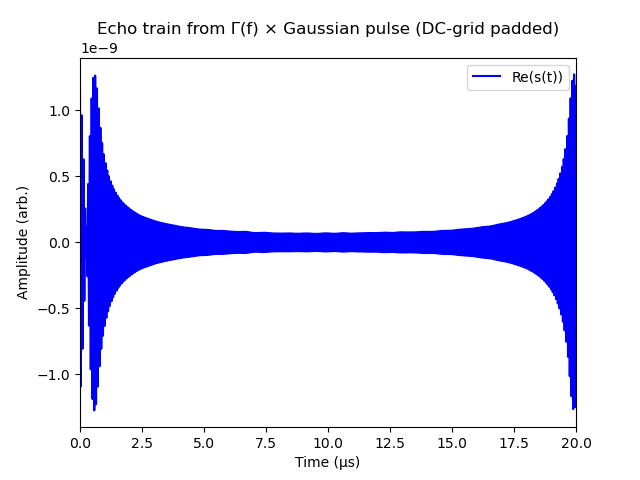

In [ ]:
##### 

# IFFT to time
t2, s_t2 = util.ifft_one_sided_to_time(f_full2, S_full2, pad_factor=8, make_real=True,scale_physical=True,analytic_preserve_amplitude= True,window='taper',f_lo=min(freqs), f_hi=max(freqs), taper_frac=0.05)

fig, ax = plt.subplots()

ax.plot(t2*1e6, np.real(s_t2), label="Re(s(t))",       color="blue")

ax.set_xlabel("Time (µs)")
ax.set_ylabel("Amplitude (arb.)")
ax.set_title("Echo train from Γ(f) × Gaussian pulse (DC-grid padded)")
ax.set_xlim(0, 20)
#ax.set_ylim(-32e-6, 32e-6)

ax.legend()
#fig.tight_layout()
#fig.savefig("echo_train.png", dpi=300, bbox_inches="tight")
plt.show()

